In [8]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import geopandas as gpd
from shapely.geometry import Polygon, Point

from unidecode import unidecode
# function_collection import *

In [9]:
# parameters
region_level = "nuts4"
year = 2017

**Figure 1 -- to be discussed**

In [ ]:
# example on coagglomeration -- a relative high ind-ind pair in all measures
# position in coagg distribution (3 different, so it is tough)
# labor flow
# IO connections

# maybe -- 2 rows -- one about the above and on a counter example

In [16]:
df = pd.read_csv(f"../data/oc15_2023_dec/04oc_data_{region_level}_{year}.csv", sep=";")

In [ ]:
# industry-region table -- industry-region pair that coagglomerates -- that does not coagglomerate

**Figure 2 - distance based plots**

In [11]:
# OC data in
ddf = pd.read_csv("../data/oc15_2023_dec/oc_distance_io_labor_ties.csv", sep=";")
ddf = ddf.fillna(0)

In [12]:
# calculate probabilities
ddf["pr_io"] = ddf["obs_io"] / ddf["poss_ties"]
ddf["pr_labor"] = ddf["obs_labor"] / ddf["poss_ties"]
ddf["pr_overlap"] = ddf["obs_overlap"] / ddf["poss_ties"]

# log transformation
columns_log1 = ["dist_int", "obs_io", "obs_labor", "obs_overlap", "nr_io_ties", "nr_io_sr_flow_ties", "nr_io_sr_noflow_ties"]
ddf[[f"log_{col}" for col in columns_log1]] = ddf[columns_log1].apply(lambda x: np.log10(x + 1))
columns_log = ["pr_io", "pr_labor", "pr_overlap"]
ddf[[f"log_{col}" for col in columns_log]] = ddf[columns_log].apply(lambda x: np.log10(x))

/opt/homebrew/lib/python3.10/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


In [13]:
# calculations for SR / no-SR supplier connections
ddf["nr_io_no_sr_ties"] = ddf["io_diff_ind"] - ddf["nr_io_sr_ties"]
ddf["nr_io_no_sr_ties_total"] = ddf["nr_io_no_sr_ties"].sum()
ddf["nr_io_sr_ties_total"] = ddf["nr_io_sr_ties"].sum()

# shares
ddf["share_io_no_sr_ties"] = ddf["nr_io_no_sr_ties"] / ddf["nr_io_no_sr_ties_total"]
ddf["share_io_sr_ties"] = ddf["nr_io_sr_ties"] / ddf["nr_io_sr_ties_total"]

# confidence intervals
ddf["se_for_plot"] = np.sqrt(ddf["share_io_sr_ties"]*(1-ddf["share_io_sr_ties"])) / np.sqrt(ddf["nr_io_sr_ties_total"])
ddf["share_io_no_sr_ties_U"] = ddf["share_io_no_sr_ties"] - 1.96*(ddf["se_for_plot"])
ddf["share_io_no_sr_ties_L"] = ddf["share_io_no_sr_ties"] + 1.96*(ddf["se_for_plot"])

In [14]:
def tie_distance(df, distance_column, key_info, return_table, fontsize, yaxis_text, ax=None):
    """function for different x: distance y: ties plots"""
    
    # data preparation
    all_columns = distance_column + list(key_info.keys())
    df = df[all_columns]
    if return_table==True:
        return df

    # figure preparation
    if ax is None:
        ax = plt.gca()
    for key, value in key_info.items():
        ax.plot(df[distance_column], df[key], "o--", color=value, markersize=5, linewidth=2, alpha=0.75)
        #ax.semilogy()
        #ax.set_xlim(-10, 800)
        ax.set_xlabel("Distance km (log)", size=fontsize)
        ax.set_ylabel(yaxis_text, size=fontsize)
        ax.tick_params("x", labelsize=(fontsize-5))
        ax.tick_params("y", labelsize=(fontsize-5))
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

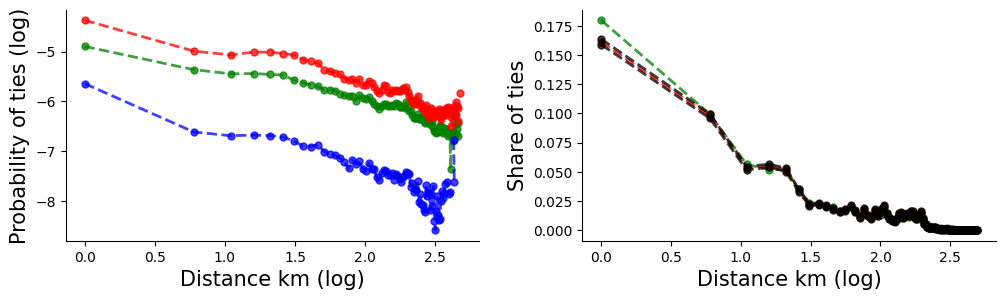

In [15]:
# distance decay figure
fig, ax = plt.subplots(1,2, figsize=(12,3))
plt.subplots_adjust(wspace=0.25)

# probability of ties
input_dict = {"log_pr_io":"green", "log_pr_labor":"red", "log_pr_overlap":"blue"}
tie_distance(ddf, distance_column=["log_dist_int"], key_info=input_dict, return_table=False, fontsize=15, yaxis_text="Probability of ties (log)", ax=ax[0])
# ax[0].set_xticks
# ax[0].set_yticks

# share of IO ties by SR / no-SR
input_dict = {"share_io_sr_ties":"green", "share_io_no_sr_ties":"red", "share_io_no_sr_ties_U":"black", "share_io_no_sr_ties_L":"black"}
#input_dict = {"share_io_sr_ties":"green", "share_io_no_sr_ties":"red"}
tie_distance(ddf, distance_column=["log_dist_int"], key_info=input_dict, return_table=False, fontsize=15, yaxis_text="Share of ties", ax=ax[1])

In [ ]:
# missing
# y axis log for ax[0]
# x axis log for both
# legends..
# confidence intervals by shades for ax[1]


# separately for manufacturing and services

In [21]:
ddf["nr_io_no_sr_ties"] = ddf["io_diff_ind"] - ddf["nr_io_sr_ties"]
ddf["nr_io_no_sr_ties_total"] = ddf["nr_io_no_sr_ties"].sum()
ddf["nr_io_sr_ties_total"] = ddf["nr_io_sr_ties"].sum()


ddf["share_io_no_sr_ties"] = ddf["nr_io_no_sr_ties"] / ddf["nr_io_no_sr_ties_total"]
ddf["share_io_sr_ties"] = ddf["nr_io_sr_ties"] / ddf["nr_io_sr_ties_total"]

In [29]:
ddf["se_for_plot"] = np.sqrt(ddf["share_io_sr_ties"]*(1-ddf["share_io_sr_ties"])) / np.sqrt(ddf["nr_io_sr_ties_total"])

ddf["share_io_no_sr_ties_U"] = ddf["share_io_no_sr_ties"] - 1.96*(ddf["se_for_plot"])
ddf["share_io_no_sr_ties_L"] = ddf["share_io_no_sr_ties"] + 1.96*(ddf["se_for_plot"])

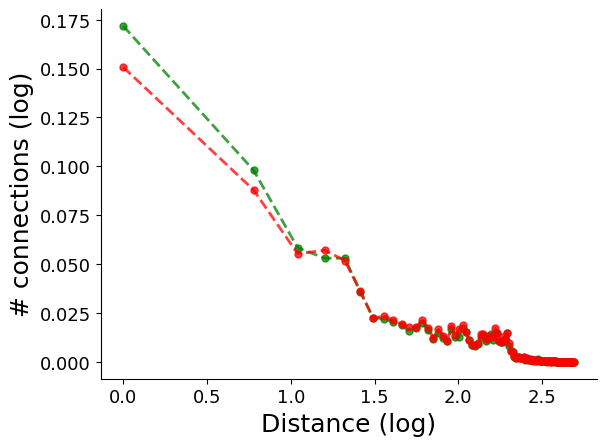

In [31]:
#input_dict = {"share_io_sr_ties":"green", "share_io_no_sr_ties":"red", "share_io_no_sr_ties_U":"black", "share_io_no_sr_ties_L":"black"}
input_dict = {"share_io_sr_ties":"green", "share_io_no_sr_ties":"red"}
tie_distance(ddf, distance_column=["log_dist"], key_info=input_dict, return_table=False, fontsize=18)

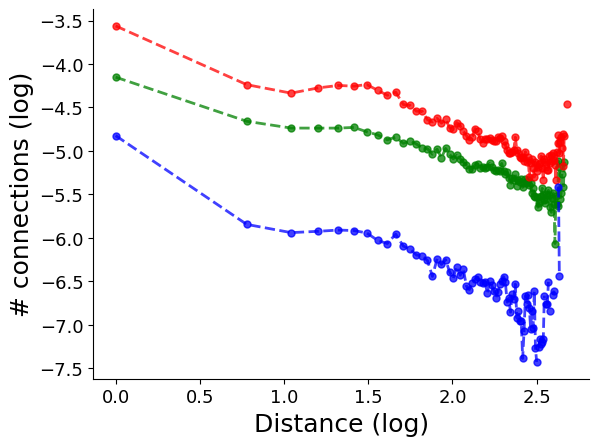

In [53]:
#input_dict = {"pr_io":"green", "pr_labor":"red"}
input_dict = {"pr_io":"green", "pr_labor":"red", "pr_overlap":"blue"}
tie_distance(ddf, distance_column=["log_dist"], key_info=input_dict, return_table=False, fontsize=18)

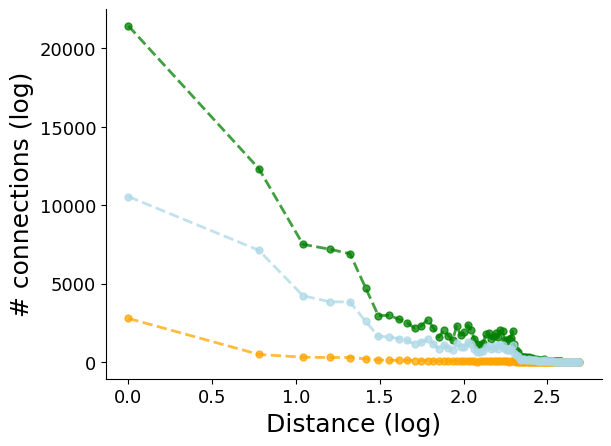

In [54]:
input_dict = {"nr_io_ties":"green", "nr_io_sr_flow_ties":"orange", "nr_io_sr_noflow_ties":"lightblue"}
tie_distance(ddf, distance_column=["log_dist"], key_info=input_dict, return_table=False, fontsize=18)

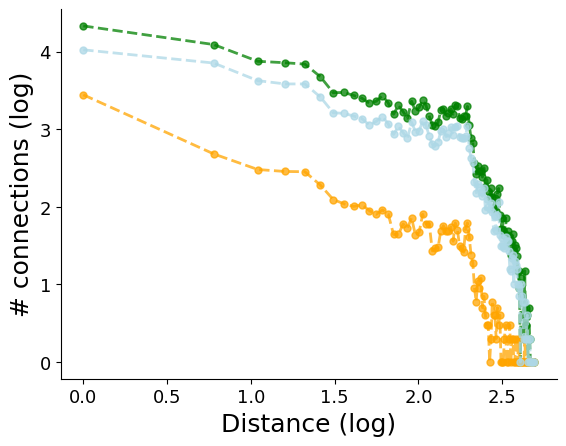

In [56]:
input_dict = {"log_nr_io_ties":"green", "log_nr_io_sr_flow_ties":"orange", "log_nr_io_sr_noflow_ties":"lightblue"}
tie_distance(ddf, distance_column=["log_dist"], key_info=input_dict, return_table=False, fontsize=18)

**Figure x - coagglomeration, IO connections, labor flow**

In [26]:
# load data
df3 = pd.read_csv(f"../data/oc10_2023_sep/oc_mdf3_{region_level}_{year}_based.csv", sep=";")

In [33]:
def z_score(values):
    new_values = (values - np.mean(values)) / (np.max(values) - np.min(values))
    return new_values

In [36]:
# variables manipulation
df3["coagg_stand"] = z_score(df3["egk_coagg"])
df3["io_stand"] = z_score(df3["io_norm"])
df3["lab_stand"] = z_score(df3["sr_norm"])

# clear setting
columns_to_consider = ["coagg_porter", "coagg_porter_mne", "coagg_porter_local", "io_stand", "lab_stand"]
df3 = df3.dropna(subset=columns_to_consider)

In [38]:
def matrix_represantation(df, key_columns, sort_matrix, heatmap, fontsize, title_text, cmap, ax=None):
    """matrix or pivot table representation of our key variables"""
    table = df[key_columns]

    # undirected to directed -- to have a full matrix
    table2 = table.copy().rename(columns={"ind1": "ind2", "ind2": "ind1"})
    table2 = table2[key_columns]
    table = pd.concat([table, table2])

    # pivot transformation
    table = pd.pivot_table(table,
        values=key_columns[2],
        index=key_columns[0],
        columns=key_columns[1],
        aggfunc=np.max,
        margins=True,
        margins_name='total')

    # option to sort the matrix
    if sort_matrix == True:
        table = table\
            .sort_values(by=["total"], ascending=False, axis=0)\
            .sort_values(by=["total"], ascending=False, axis=1)
    else:
        table = table
    
    table = table.drop(["total"], axis=1).drop(["total"], axis=0)
    
    # option to keep the table or create heatmap
    if heatmap==False:
        return table
    else:
        if ax is None:
            ax = plt.gca()
        sns.heatmap(table, cbar=False, cmap=cmap, ax=ax)
        ax.set_xlabel("Industry", size=fontsize)
        ax.set_ylabel("Industry", size=fontsize)
        ax.set_title(title_text, size=fontsize)
        ax.yaxis.set_tick_params(rotation=0, labelbottom=True)
        #ax.set_xticklabels("")
        #ax.set_yticklabels("")
        ax.tick_params(left = False, bottom = False)

In [41]:
# matrix_represantation(df3, key_columns=["ind1", "ind2", "coagg_stand"], sort_matrix=False, heatmap=True, fontsize=25, title_text="EGK coagglomeration", cmap="Blues")

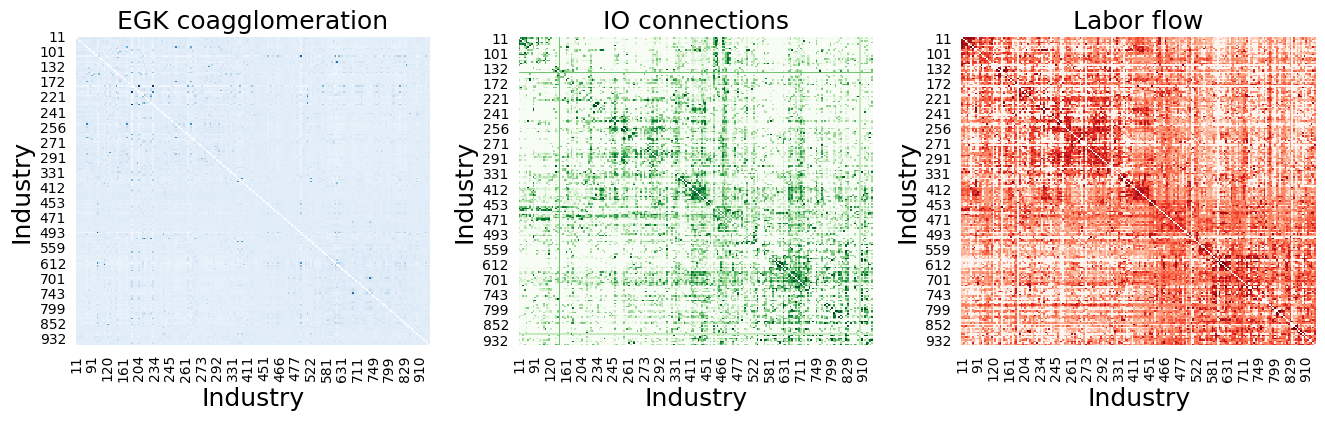

In [42]:
fig, ax = plt.subplots(1,3, figsize=(16,4), sharex=True, sharey=True)
plt.subplots_adjust(wspace=0.25)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "coagg_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="EGK coagglomeration",
    cmap="Blues",
    ax=ax[0]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "io_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="IO connections",
    cmap="Greens",
    ax=ax[1]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "lab_stand"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Labor flow",
    cmap="Reds",
    ax=ax[2]
)

In [43]:
# add kde plots below the matrix row
def density_plot(df, key_column, colorway, xlabel_text, fontsize, ax=None):
    if ax is None:
        ax = plt.gca()
    if ax is None:
        ax = plt.gca()

    sns.kdeplot(data=df,
        x=key_column,
        fill=True,
        color=colorway,
        linewidth=2.5,
        log_scale=False,
        ax=ax)
    
    ax.set_xlabel(xlabel_text, size=fontsize)
    ax.set_ylabel("Density", size=fontsize)
    ax.tick_params("x", labelsize=(fontsize-5))
    ax.tick_params("y", labelsize=(fontsize-5))
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

In [69]:
# density_plot(df3, key_column="coagg_stand", colorway = "#2C728EFF", xlabel_text="EGK coagglomeration", fontsize=15)

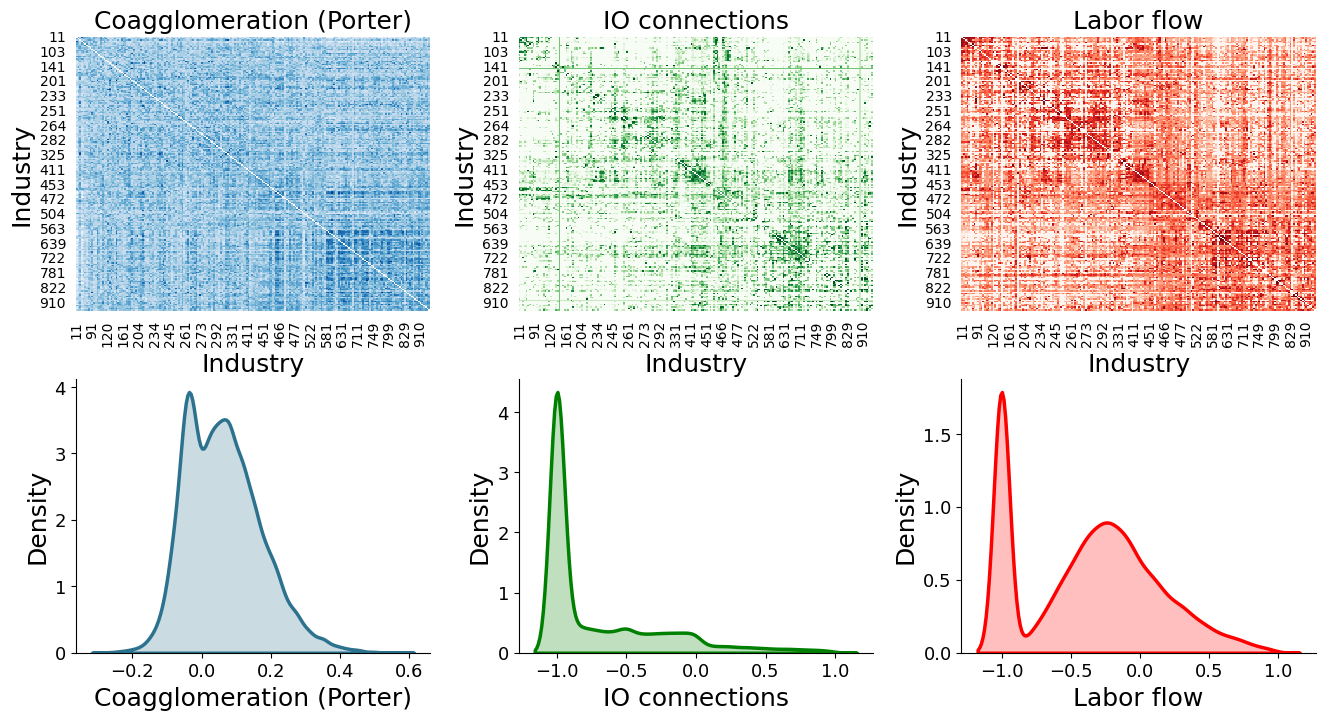

In [52]:
fig, ax = plt.subplots(2,3, figsize=(16,8))
plt.subplots_adjust(wspace=0.25, hspace=0.25)

matrix_represantation(
    df3,
    #key_columns=["ind1", "ind2", "egk_coagg"],
    key_columns=["ind1", "ind2", "coagg_porter"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Coagglomeration (Porter)",
    cmap="Blues",
    ax=ax[0,0]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "io_norm"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="IO connections",
    cmap="Greens",
    ax=ax[0,1]
)

matrix_represantation(
    df3,
    key_columns=["ind1", "ind2", "sr_norm"],
    sort_matrix=False,
    heatmap=True,
    fontsize=18,
    title_text="Labor flow",
    cmap="Reds",
    ax=ax[0,2]
)

density_plot(
    df3,
    #key_column="egk_coagg",
    key_column="coagg_porter",
    colorway="#2C728EFF",
    xlabel_text="Coagglomeration (Porter)",
    fontsize=18,
    ax=ax[1,0]
)

density_plot(
    df3,
    key_column="io_norm",
    colorway="Green",
    xlabel_text="IO connections",
    fontsize=18,
    ax=ax[1,1]
)

density_plot(
    df3,
    key_column="sr_norm",
    colorway="Red",
    xlabel_text="Labor flow",
    fontsize=18,
    ax=ax[1,2]
)
